# =============================================================================
# PARTIE 3 — Prédiction de genre & recommandation depuis les synopsis
# =============================================================================


In [3]:
# ─── 1. Chargement et EDA ────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv("movie_plots.csv")
print(data.shape)
print(data.head())
print(data.info())

data.isnull().sum()

(5385, 3)
   movie_poster_path                                         movie_plot  \
0  action/100108.jpg  The movie "Parker" is a thrilling action film ...   
1  action/100192.jpg  The movie "Ironclads" is a historical drama se...   
2  action/100404.jpg  The movie "Rainy Dog" is a gripping and intens...   
3  action/101761.jpg  Welcome to the Punch is a thrilling action fil...   
4  action/102051.jpg  The movie "Iron Man: Rise of Technovores" is a...   

  movie_category  
0         action  
1         action  
2         action  
3         action  
4         action  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5385 entries, 0 to 5384
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   movie_poster_path  5385 non-null   object
 1   movie_plot         5385 non-null   object
 2   movie_category     5385 non-null   object
dtypes: object(3)
memory usage: 126.3+ KB
None


movie_poster_path    0
movie_plot           0
movie_category       0
dtype: int64

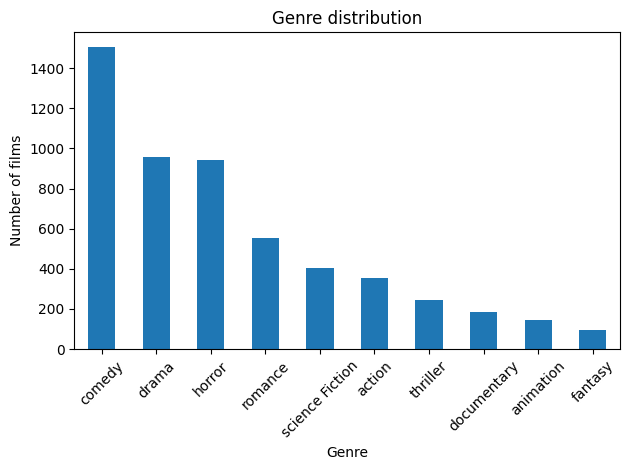

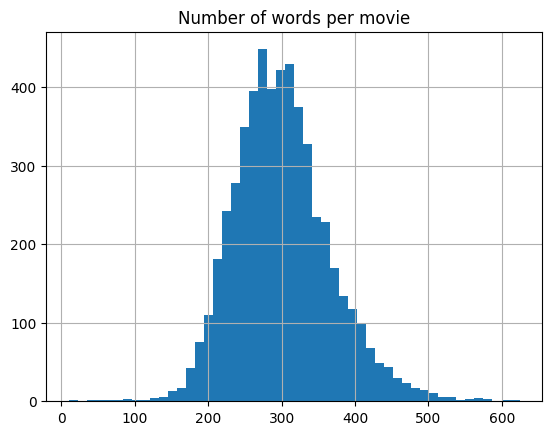

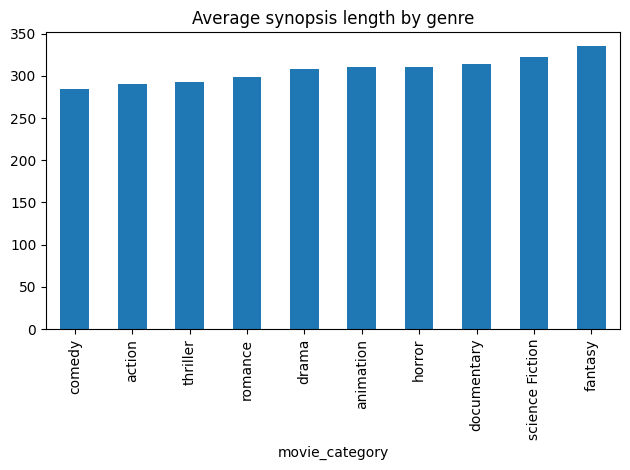

In [5]:
# Distribution des genres
data['movie_category'].value_counts().plot(kind='bar')
plt.title("Genre distribution")
plt.xlabel("Genre")
plt.ylabel("Number of films")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Longueur des synopsis
data['plot_length'] = data["movie_plot"].apply(len)
data['word_count'] = data['movie_plot'].apply(lambda x: len(x.split()))
data['word_count'].hist(bins=50)
plt.title("Number of words per movie")
plt.show()

data.groupby('movie_category')['word_count'].mean().sort_values().plot(kind='bar')
plt.title("Average synopsis length by genre")
plt.tight_layout()
plt.show()


# 2. Préparation des données ───────────────────────────────────────────────


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle

In [7]:
data_nlp = data.drop('movie_poster_path', axis=1)

train_data, test_data = train_test_split(
    data_nlp,
    test_size=0.2,
    stratify=data_nlp['movie_category'],
    random_state=42
)

In [8]:
le = LabelEncoder()
train_data = train_data.copy()
test_data = test_data.copy()
train_data['label'] = le.fit_transform(train_data['movie_category'])
test_data['label'] = le.transform(test_data['movie_category'])

mapping = dict(zip(le.transform(le.classes_), le.classes_))
print("Mapping genres :", mapping)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print("✅ LabelEncoder sauvegardé dans label_encoder.pkl")

train_text, train_labels = train_data['movie_plot'], train_data["label"]
test_text, test_labels = test_data["movie_plot"], test_data["label"]

Mapping genres : {np.int64(0): 'action', np.int64(1): 'animation', np.int64(2): 'comedy', np.int64(3): 'documentary', np.int64(4): 'drama', np.int64(5): 'fantasy', np.int64(6): 'horror', np.int64(7): 'romance', np.int64(8): 'science Fiction', np.int64(9): 'thriller'}
✅ LabelEncoder sauvegardé dans label_encoder.pkl


# 3. Tokenisation ──────────────────────────────────────────────────────────


In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

c:\Users\cesar\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
class NlpDataset(Dataset):
    def __init__(self, data, labels, tokenizer):
        self.data = data.tolist()
        self.labels = labels.tolist()
        self.encodings = tokenizer(self.data, truncation=True, padding=True, max_length=512)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

full_data = data_nlp.copy()
full_data['label'] = le.transform(full_data['movie_category'])
full_text = full_data['movie_plot']
full_labels_series = full_data['label']

train_dataset = NlpDataset(train_text, train_labels, tokenizer)
test_dataset = NlpDataset(test_text, test_labels, tokenizer)
full_dataset = NlpDataset(full_text, full_labels_series, tokenizer)

#batch_size réduit à 16 pour éviter les OOM sur petite GPU/CPU
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)
full_loader = DataLoader(full_dataset, batch_size=16)  

# 4. Modèle ────────────────────────────────────────────────────────────────


In [11]:
from transformers import DistilBertForSequenceClassification
import torch.nn as nn


In [12]:
class BertClf(nn.Module):
    def __init__(self, distilbert):
        super(BertClf, self).__init__()
        self.distilbert = distilbert

        # dégeler les 2 derniers transformer blocks
        # DistilBERT a 6 layers (0 à 5). On gèle les 4 premières, on entraîne 4 et 5.
        for name, param in distilbert.named_parameters():
            param.requires_grad = False  # tout geler par défaut

        # Dégeler : transformer layer 4 et 5 + classifier
        for name, param in distilbert.named_parameters():
            if ('transformer.layer.4' in name or
                'transformer.layer.5' in name or
                'classifier' in name or
                'pre_classifier' in name):
                param.requires_grad = True

        # Afficher les paramètres entraînables
        trainable = sum(p.numel() for p in distilbert.parameters() if p.requires_grad)
        total = sum(p.numel() for p in distilbert.parameters())
        print(f"Paramètres entraînables : {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

    def forward(self, sent_id, mask):
        out = self.distilbert(sent_id, attention_mask=mask)
        logits = out.logits
        # hidden_states et attentions ne sont pas None
        # car on a bien passé output_hidden_states=True et output_attentions=True
        hidden_states = out.hidden_states  # tuple de tenseurs (une par layer)
        attn = out.attentions
        return logits, hidden_states, attn

In [13]:
num_labels_fin = train_data['label'].nunique()
print(f"Nombre de genres : {num_labels_fin}")

distilbert = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels_fin,
    output_attentions=True,
    output_hidden_states=True
)
model = BertClf(distilbert)

Nombre de genres : 10


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6964.27it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Paramètres entraînables : 14,774,026 / 66,961,162 (22.1%)


# 5. Entraînement ──────────────────────────────────────────────────────────


In [14]:
from tqdm import tqdm
from torch.optim import AdamW


In [15]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
model = model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

Device : cpu


In [17]:
from transformers import get_linear_schedule_with_warmup

n_epochs = 5  
total_steps = len(train_loader) * n_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,  # 10% de warmup
    num_training_steps=total_steps
)


def train_bert(model, optimizer, scheduler, dataloader, epochs):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        running_corrects = 0
        total = 0
        t = tqdm(dataloader)
        for i, batch in enumerate(t):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            preds, _, _ = model(input_ids, mask=attention_mask)
            loss = criterion(preds, labels)

            optimizer.zero_grad()
            loss.backward()
            # gradient clipping pour éviter les explosions de gradient
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step() 

            _, predicted = preds.max(1)
            running_corrects += predicted.eq(labels).sum().item()
            total += labels.size(0)
            running_loss += loss.item()

            t.set_description(
                f"epoch:{epoch+1}/{epochs} loss:{running_loss/(i+1):.4f} "
                f"acc:{running_corrects/total*100:.2f}%"
            )


def test_bert(model, dataloader):
    model.eval()
    test_corrects = 0
    total = 0
    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            preds, _, _ = model(input_ids, mask=attention_mask)
            _, predicted = preds.max(1)
            test_corrects += predicted.eq(labels).sum().item()
            total += labels.size(0)
    acc = test_corrects / total
    print(f"Test accuracy : {acc*100:.2f}%")
    return acc


train_bert(model, optimizer, scheduler, train_loader, n_epochs)
test_bert(model, test_loader)

# Sauvegarder les poids
torch.save(model.state_dict(), "bert_model_weights_1.pth")
print("Poids sauvegardés dans bert_model_weights_1.pth")


100%|██████████| 68/68 [03:08<00:00,  2.78s/it]


Test accuracy : 96.94%
Poids sauvegardés dans bert_model_weights_1.pth


# 6. Extraction des embeddings (TOUT le dataset) ──────────────────────────


In [18]:
import numpy as np


In [20]:
def get_embeddings(model, dataloader):
    model.eval()
    embeddings = []
    all_labels = []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Extraction embeddings"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            all_labels.extend(batch["labels"].tolist())

            _, hidden_states, _ = model(input_ids, mask=attention_mask)
            if hidden_states is None:
                raise ValueError(
                    "hidden_states est None. Vérifie que output_hidden_states=True "
                    "est bien passé à from_pretrained()."
                )

            # CLS token = index 0, dernière layer = hidden_states[-1]
            last_layer_cls = hidden_states[-1][:, 0, :]  
            embeddings.append(last_layer_cls.cpu().numpy())

    embeddings = np.vstack(embeddings)  
    return embeddings, all_labels

In [21]:
print("Extraction des embeddings sur le dataset complet...")
embeddings, labels = get_embeddings(model, full_loader)
print(f"Embeddings shape : {embeddings.shape}")

np.save("embeddings_bert_1.npy", embeddings)
np.save("labels_bert_1.npy", labels)
print("✅ Embeddings sauvegardés")

Extraction des embeddings sur le dataset complet...


Extraction embeddings: 100%|██████████| 337/337 [15:07<00:00,  2.69s/it]

Embeddings shape : (5385, 768)
✅ Embeddings sauvegardés


# 7. Sauvegarde des métadonnées pour Annoy ────────────────────────────────


In [23]:
metadata = full_data[['movie_plot', 'movie_category']].reset_index(drop=True)
metadata.to_json("annoy_metadata_bert_1.json", orient="records")
print("Métadonnées sauvegardées dans annoy_metadata_bert_1.json")
print(metadata.head())


Métadonnées sauvegardées dans annoy_metadata_bert_1.json
                                          movie_plot movie_category
0  The movie "Parker" is a thrilling action film ...         action
1  The movie "Ironclads" is a historical drama se...         action
2  The movie "Rainy Dog" is a gripping and intens...         action
3  Welcome to the Punch is a thrilling action fil...         action
4  The movie "Iron Man: Rise of Technovores" is a...         action


# 8. Construction de l'index Annoy ────────────────────────────────────────


In [24]:
from annoy import AnnoyIndex

embedding_dim = embeddings.shape[1]
annoy_index = AnnoyIndex(embedding_dim, metric="angular")

for i, emb in enumerate(embeddings):
    annoy_index.add_item(i, emb)

annoy_index.build(10)
annoy_index.save("plot_embeddings_bert_1.ann")
print(f"Index Annoy construit ({len(embeddings)} films) et sauvegardé dans plot_embeddings.ann")

Index Annoy construit (5385 films) et sauvegardé dans plot_embeddings.ann


# 9. Test de vérification de l'index ───────────────────────────────────────


In [29]:
import json

with open("annoy_metadata_bert_1.json") as f:
    meta = json.load(f)

# Test : trouver les 6 films les plus similaires (6 pour exclure le film lui-même)
query_idx = 0
query_emb = embeddings[query_idx]
similar_ids = annoy_index.get_nns_by_vector(query_emb, 6, include_distances=True)
indices, distances = similar_ids

print(f"\nFilm requête : {meta[query_idx]['movie_plot']} ({meta[query_idx]['movie_category']})")
print("\nFilms les plus similaires :")
for idx, dist in zip(indices, distances):
    if idx == query_idx:  # exclure le film lui-même
        continue
    print(f"  [{dist:.4f}] {meta[idx]['movie_plot']} — {meta[idx]['movie_category']}")


Film requête : The movie "Parker" is a thrilling action film that follows the story of Parker, a former assassin who has been living a quiet life in a small town. However, when his estranged brother, a notorious criminal, is arrested and sentenced to death, Parker is forced to return to the world of crime to help him escape.

As Parker navigates the dangerous underworld, he must also confront his own past and the choices he made as an assassin. Along the way, he encounters a cast of colorful characters, including a corrupt police officer, a skilled hacker, and a mysterious woman who becomes his ally.

As the stakes grow higher, Parker must use all of his skills and cunning to outsmart his enemies and protect his brother from the clutches of the law. But with each new challenge, he must also grapple with the moral implications of his actions and the consequences they may have on those around him.

In the end, Parker must make a difficult decision: will he continue to fight for justice,